In [1]:
import os
print(os.getcwd())

/Users/dts/projects/protein-function-ml/notebooks


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

df = pd.read_csv("../data/processed/features.csv")
feature_cols = [c for c in df.columns if c not in ("Entry", "function_category")]
X = df[feature_cols].values
y = df["function_category"].values
print(X.shape, y.shape)

(9961, 426) (9961,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42,
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print(pd.Series(y_train).value_counts(normalize=True).round(3))
print(pd.Series(y_test).value_counts(normalize=True).round(3))

Train: (7968, 426)  Test: (1993, 426)
enzyme                  0.463
transcription_factor    0.195
transporter             0.150
receptor                0.132
structural_protein      0.060
Name: proportion, dtype: float64
enzyme                  0.463
transcription_factor    0.195
transporter             0.150
receptor                0.132
structural_protein      0.060
Name: proportion, dtype: float64


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
log_reg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr))

                      precision    recall  f1-score   support

              enzyme       0.83      0.62      0.71       923
            receptor       0.64      0.82      0.72       263
  structural_protein       0.34      0.62      0.44       120
transcription_factor       0.73      0.76      0.75       388
         transporter       0.43      0.51      0.46       299

            accuracy                           0.65      1993
           macro avg       0.60      0.66      0.62      1993
        weighted avg       0.70      0.65      0.66      1993



In [6]:
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # unscaled — tree splits don't care about feature scale

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

                      precision    recall  f1-score   support

              enzyme       0.76      0.87      0.81       923
            receptor       0.82      0.77      0.79       263
  structural_protein       0.81      0.57      0.67       120
transcription_factor       0.76      0.80      0.78       388
         transporter       0.72      0.44      0.54       299

            accuracy                           0.76      1993
           macro avg       0.77      0.69      0.72      1993
        weighted avg       0.76      0.76      0.75      1993



In [7]:
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train_enc)

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    objective="multi:softprob", eval_metric="mlogloss",
    random_state=42, n_jobs=-1,
)
xgb.fit(X_train, y_train_enc, sample_weight=sample_weights)

y_pred_xgb = label_encoder.inverse_transform(xgb.predict(X_test))
print(classification_report(y_test, y_pred_xgb))

                      precision    recall  f1-score   support

              enzyme       0.77      0.90      0.83       923
            receptor       0.85      0.82      0.83       263
  structural_protein       0.86      0.56      0.68       120
transcription_factor       0.83      0.78      0.80       388
         transporter       0.72      0.53      0.61       299

            accuracy                           0.79      1993
           macro avg       0.81      0.72      0.75      1993
        weighted avg       0.79      0.79      0.78      1993



In [8]:
results = []
for name, y_pred in [("Logistic Regression", y_pred_lr), ("Random Forest", y_pred_rf), ("XGBoost", y_pred_xgb)]:
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "weighted_f1": f1_score(y_test, y_pred, average="weighted"),
    })

results_df = pd.DataFrame(results).set_index("model")
results_df.round(3)

,accuracy,macro_f1,weighted_f1
model,,,
Logistic Regression,0.654,0.616,0.664
Random Forest,0.763,0.719,0.754
XGBoost,0.788,0.751,0.782


Best by macro F1: XGBoost


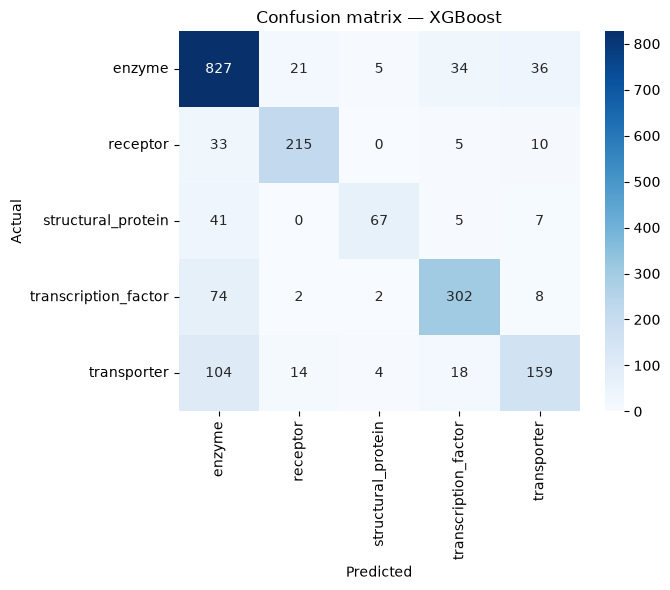

In [9]:
best_model_name = results_df["macro_f1"].idxmax()
print("Best by macro F1:", best_model_name)

y_pred_map = {"Logistic Regression": y_pred_lr, "Random Forest": y_pred_rf, "XGBoost": y_pred_xgb}
labels_order = sorted(df["function_category"].unique())
cm = confusion_matrix(y_test, y_pred_map[best_model_name], labels=labels_order)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion matrix — {best_model_name}")
plt.tight_layout()
plt.savefig("../results/figures/confusion_matrix_best_model.png", dpi=150)
plt.show()

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg_pipeline = Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))])
rf_for_cv = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)

for name, model in [("Logistic Regression", log_reg_pipeline), ("Random Forest", rf_for_cv)]:
    scores = cross_validate(model, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)["test_score"]
    print(f"{name}: {scores.mean():.3f} +/- {scores.std():.3f}")

# XGBoost needs label-encoding and sample weights per fold, so it gets its own loop
xgb_scores = []
for train_idx, val_idx in cv.split(X, y):
    y_tr_enc = label_encoder.transform(y[train_idx])
    y_val_enc = label_encoder.transform(y[val_idx])
    weights = compute_sample_weight("balanced", y=y_tr_enc)
    model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                           objective="multi:softprob", eval_metric="mlogloss",
                           random_state=42, n_jobs=-1)
    model.fit(X[train_idx], y_tr_enc, sample_weight=weights)
    xgb_scores.append(f1_score(y_val_enc, model.predict(X[val_idx]), average="macro"))

xgb_scores = np.array(xgb_scores)
print(f"XGBoost: {xgb_scores.mean():.3f} +/- {xgb_scores.std():.3f}")

Logistic Regression: 0.624 +/- 0.011
Random Forest: 0.722 +/- 0.010
XGBoost: 0.754 +/- 0.011


In [12]:
import joblib
from pathlib import Path

Path("../models").mkdir(exist_ok=True)

joblib.dump({
    "model_name": best_model_name,
    "model": {"Logistic Regression": log_reg, "Random Forest": rf, "XGBoost": xgb}[best_model_name],
    "scaler": scaler,
    "label_encoder": label_encoder,
    "feature_cols": feature_cols,
}, "../models/best_model.joblib")

print(f"Saved {best_model_name} to models/best_model.joblib")

Saved XGBoost to models/best_model.joblib
